In [12]:
# === Method A: Destination-label shuffle permutation test (col-space only) ===
from pathlib import Path
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------
# Config
# -----------------------
MAP_DIR = "subspace_channel_analysis_r64"   # directory containing the learned W^{l->k} .pt maps
TOL = 1e-6
DEVICE_FOR_SVD = "cuda"           # 안정성 우선. "cuda"도 가능
MAX_K = None                     # principal angles 개수 제한 (예: 256). None이면 min(rank0,rank1)
NUM_PERM = 10000                  # permutation 횟수
SEED = 42

# -----------------------
# 1) Load .pt maps (W_col) and destination labels (target)
# -----------------------
pt_files = sorted(Path(MAP_DIR).glob("*.pt"))
assert len(pt_files) > 0, f"No .pt files found in {MAP_DIR}"

def parse_s_t_from_filename(name: str):
    m = re.search(r"(\d+)_to_(\d+)", name)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

records = []
for p in pt_files:
    ckpt = torch.load(p, map_location="cpu")

    s = ckpt.get("source_layer", None)
    t = ckpt.get("target_layer", None)
    if s is None or t is None:
        s2, t2 = parse_s_t_from_filename(p.name)
        s, t = s2, t2
    if s is None or t is None:
        continue

    W = ckpt.get("W", None)
    if W is None:
        A = ckpt.get("A", None)
        B = ckpt.get("B", None)
        if A is not None and B is not None:
            W = (B @ A)
    if W is None:
        continue

    records.append({
        "s": int(s),
        "t": int(t),                 # destination label
        "W": W.detach().cpu().float(),
        "path": str(p),
        "N": int(ckpt.get("N", -1)) if ckpt.get("N", None) is not None else -1,
    })

assert len(records) > 0, "No valid maps loaded."
records.sort(key=lambda r: (r["s"], r["t"]))

keys = [(r["s"], r["t"]) for r in records]
Ts = np.array([r["t"] for r in records], dtype=int)
Ws = [r["W"] for r in records]
n = len(Ws)

n_layers = 1 + int(max(max(s,t) for (s,t) in keys))
print(f"Loaded maps n={n} | inferred n_layers={n_layers}")
print("Example:", keys[0], records[0]["path"])

# -----------------------
# 2) Col-space overlap: precompute orth bases Q_i once
# -----------------------
def orth(U: torch.Tensor, tol: float = 1e-6, device: str = "cpu") -> torch.Tensor:
    """
    U: [d, d] or [d, r]
    Return orthonormal basis Q of col(U), robust under rank deficiency.
    """
    U = U.to(device=device, dtype=torch.float32)
    u, s, _ = torch.linalg.svd(U, full_matrices=False)
    if s.numel() == 0:
        return u[:, :0]
    r_eff = int((s > tol * s.max()).sum().item())
    return u[:, :r_eff]

@torch.no_grad()
def overlap_from_Q(Q0: torch.Tensor, Q1: torch.Tensor, max_k=None) -> float:
    """
    overlap = mean cos^2(theta_i), theta_i are principal angles
    """
    k = min(Q0.shape[1], Q1.shape[1])
    if max_k is not None:
        k = min(k, int(max_k))
    if k == 0:
        return float("nan")
    M = (Q0[:, :k].T @ Q1[:, :k]).to(dtype=torch.float32)
    s = torch.linalg.svdvals(M).clamp(0, 1)
    return float((s**2).mean().item())

print("Precomputing Q bases (col space) ...")
Qs = [orth(W, tol=TOL, device=DEVICE_FOR_SVD) for W in Ws]
ranks = np.array([Q.shape[1] for Q in Qs], dtype=int)
print(f"rank stats: min={ranks.min()}, median={int(np.median(ranks))}, max={ranks.max()}")

# -----------------------
# 3) Pairwise overlap matrix sim_col (n x n)
# -----------------------
print("Computing pairwise overlap matrix sim_col ...")
sim_col = np.full((n, n), np.nan, dtype=np.float32)
np.fill_diagonal(sim_col, 1.0)

for i in range(n):
    Qi = Qs[i]
    for j in range(i+1, n):
        ov = overlap_from_Q(Qi, Qs[j], max_k=MAX_K)
        sim_col[i, j] = ov
        sim_col[j, i] = ov

print("sim_col range:", np.nanmin(sim_col), np.nanmax(sim_col))

# -----------------------
# 4) Split within/between by destination (target label)
# -----------------------
def upper_tri_pairs(n):
    I, J = np.triu_indices(n, k=1)
    return I, J

def split_within_between(sim, labels):
    I, J = upper_tri_pairs(sim.shape[0])
    same = (labels[I] == labels[J])
    w = sim[I[same], J[same]]
    b = sim[I[~same], J[~same]]
    w = w[~np.isnan(w)]
    b = b[~np.isnan(b)]
    return w.astype(np.float64), b.astype(np.float64)

within, between = split_within_between(sim_col, Ts)

print(f"within pairs:  {within.size}")
print(f"between pairs: {between.size}")
print(f"within mean={within.mean():.4f}, std={within.std(ddof=1):.4f}")
print(f"between mean={between.mean():.4f}, std={between.std(ddof=1):.4f}")

# -----------------------
# 5) Effect sizes: Δmean, AUC (= P(within > between) + 0.5 P(=))
# -----------------------
def auc_prob_greater(x, y, max_pairs=200000, seed=0):
    rng = np.random.default_rng(seed)
    x = x.astype(np.float64); y = y.astype(np.float64)
    nx, ny = len(x), len(y)
    total = nx * ny
    if total <= max_pairs:
        X = x[:, None]
        Y = y[None, :]
        return float((X > Y).mean() + 0.5 * (X == Y).mean())
    m = max_pairs
    xi = rng.integers(0, nx, size=m)
    yi = rng.integers(0, ny, size=m)
    gt = (x[xi] > y[yi]).mean()
    eq = (x[xi] == y[yi]).mean()
    return float(gt + 0.5 * eq)

dmean_obs = float(within.mean() - between.mean())
auc_obs = auc_prob_greater(within, between, seed=SEED)

print("\nObserved effect:")
print(f"  Δmean = {dmean_obs:.6f}")
print(f"  AUC   = {auc_obs:.6f}  (0.5=no separation, 1.0=perfect within>between)")

# -----------------------
# 6) Permutation test (destination label shuffle), one-sided
# -----------------------
rng = np.random.default_rng(SEED)

def perm_stat(sim, labels, stat="dmean", seed=0):
    w, b = split_within_between(sim, labels)
    if stat == "dmean":
        return float(w.mean() - b.mean())
    elif stat == "auc":
        return float(auc_prob_greater(w, b, seed=seed))
    else:
        raise ValueError("stat must be 'dmean' or 'auc'")

def permutation_test(sim, labels, stat="dmean", num_perm=5000, seed=42, obs=None):
    rng = np.random.default_rng(seed)
    if obs is None:
        obs = perm_stat(sim, labels, stat=stat, seed=seed)
    cnt = 0
    for k in range(num_perm):
        perm = rng.permutation(labels)
        val = perm_stat(sim, perm, stat=stat, seed=int(rng.integers(0, 1_000_000)))
        if val >= obs:  # one-sided: within이 더 크다
            cnt += 1
    p = (cnt + 1) / (num_perm + 1)
    return float(p)

p_dmean = permutation_test(sim_col, Ts, stat="dmean", num_perm=NUM_PERM, seed=SEED, obs=dmean_obs)
p_auc   = permutation_test(sim_col, Ts, stat="auc",   num_perm=NUM_PERM, seed=SEED, obs=auc_obs)

print("\nPermutation test (destination label shuffle), one-sided:")
print(f"  p-value (Δmean) = {p_dmean:.6f}  (NUM_PERM={NUM_PERM})")
print(f"  p-value (AUC)   = {p_auc:.6f}  (NUM_PERM={NUM_PERM})")

Loaded maps n=66 | inferred n_layers=12
Example: (0, 1) subspace_channel_analysis_r64/full_map_0_to_1.pt
Precomputing Q bases (col space) ...
rank stats: min=64, median=64, max=65
Computing pairwise overlap matrix sim_col ...
sim_col range: 0.09093042 1.0
within pairs:  220
between pairs: 1925
within mean=0.5670, std=0.0516
between mean=0.1509, std=0.0480

Observed effect:
  Δmean = 0.416115
  AUC   = 1.000000  (0.5=no separation, 1.0=perfect within>between)

Permutation test (destination label shuffle), one-sided:
  p-value (Δmean) = 0.000100  (NUM_PERM=10000)
  p-value (AUC)   = 0.000100  (NUM_PERM=10000)


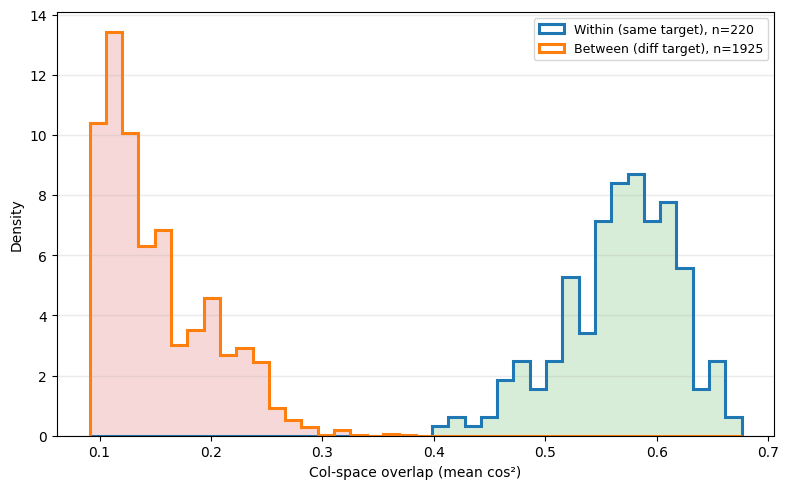

In [16]:
# -----------------------
# 7) Visualize distributions (DENSITY)
# -----------------------
allv = np.concatenate([within, between])
bin_edges = np.histogram_bin_edges(allv, bins=40)

w_mean, b_mean = np.mean(within), np.mean(between)
w_med,  b_med  = np.median(within), np.median(between)

fig = plt.figure(figsize=(8, 5))

# 1) outline(선)로 먼저 그려서 형태가 잘 보이게
plt.hist(within,  bins=bin_edges, density=True, histtype="step", linewidth=2.2,
         label=f"Within (same target), n={within.size}")
plt.hist(between, bins=bin_edges, density=True, histtype="step", linewidth=2.2,
         label=f"Between (diff target), n={between.size}")

# 2) 같은 bin으로 반투명 fill을 얹어 시각적 분리 강화
plt.hist(within,  bins=bin_edges, density=True, alpha=0.18)
plt.hist(between, bins=bin_edges, density=True, alpha=0.18)

# # 3) 평균/중앙값 표시 (선 스타일로 구분)
# plt.axvline(w_mean, linestyle="--", linewidth=1.8)
# plt.axvline(b_mean, linestyle="--", linewidth=1.8)
# plt.axvline(w_med,  linestyle=":",  linewidth=1.8)
# plt.axvline(b_med,  linestyle=":",  linewidth=1.8)

# 4) 제목/축/그리드/여백 정리
plt.xlabel("Col-space overlap (mean cos²)")
plt.ylabel("Density")
# plt.title("Overlap distribution: within vs between (by target)")
plt.grid(True, axis="y", alpha=0.25, linewidth=1.0)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()

# PDF로 저장
plt.savefig("overlap_distribution.pdf", format="pdf")

plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt

Ss = np.array([r["s"] for r in records], dtype=np.int32)  # source layer per map
Ts = np.array([r["t"] for r in records], dtype=np.int32)  # target layer per map

assert sim_col.shape[0] == sim_col.shape[1] == len(Ss) == len(Ts)

# -----------------------
# 1) same-source pair들에 대해 (distance, overlap) 데이터 만들기
# -----------------------
I, J = np.triu_indices(sim_col.shape[0], k=1)

same_source = (Ss[I] == Ss[J])
ov = sim_col[I, J]
valid = same_source & ~np.isnan(ov)

I2 = I[valid]
J2 = J[valid]
ov2 = ov[valid].astype(np.float64)

dist2 = np.abs(Ts[I2] - Ts[J2]).astype(np.int32)   # destination distance
src2  = Ss[I2].astype(np.int32)

# distance=0은 사실상 같은 target, 원하면 제외 가능
mask_nonzero = (dist2 > 0)
dist2_nz = dist2[mask_nonzero]
ov2_nz   = ov2[mask_nonzero]
src2_nz  = src2[mask_nonzero]

print("same-source pairs:", len(ov2), "| nonzero distance pairs:", len(ov2_nz))
print("distance range:", dist2_nz.min() if len(dist2_nz) else None, dist2_nz.max() if len(dist2_nz) else None)

# -----------------------
# 2) Spearman correlation (rank-based) + 간단 선형회귀 기울기
# -----------------------
def rankdata(a: np.ndarray) -> np.ndarray:
    # 평균 순위(ties average), scipy 없이 구현
    a = np.asarray(a)
    order = np.argsort(a, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(1, len(a) + 1, dtype=np.float64)

    # tie 처리
    sorted_a = a[order]
    i = 0
    while i < len(a):
        j = i
        while j + 1 < len(a) and sorted_a[j + 1] == sorted_a[i]:
            j += 1
        if j > i:
            avg = 0.5 * (i + j) + 1.0
            ranks[order[i:j+1]] = avg
        i = j + 1
    return ranks

def spearman_corr(x: np.ndarray, y: np.ndarray) -> float:
    rx = rankdata(x)
    ry = rankdata(y)
    rx = (rx - rx.mean()) / (rx.std(ddof=0) + 1e-12)
    ry = (ry - ry.mean()) / (ry.std(ddof=0) + 1e-12)
    return float((rx * ry).mean())

rho_obs = spearman_corr(dist2_nz, ov2_nz)

# 선형회귀(참고용): ov ≈ a + b * dist, b<0 기대
b, a = np.polyfit(dist2_nz.astype(np.float64), ov2_nz, deg=1)
print(f"Spearman rho(dist, overlap) = {rho_obs:.6f}  (expect negative)")
print(f"Linear fit: overlap ≈ {a:.6f} + ({b:.6f}) * dist  (slope expect negative)")

# -----------------------
# 3) Permutation test: source별로 target 라벨을 셔플해서 rho 귀무분포 만들기
# -----------------------
def permutation_pvalue_sourcewise(dist_I: np.ndarray, dist_J: np.ndarray, ov_pair: np.ndarray,
                                  Ss: np.ndarray, Ts: np.ndarray,
                                  num_perm=5000, seed=42):
    """
    dist_I, dist_J: pair index arrays (I2, J2) for same-source pairs
    ov_pair: overlap values for those pairs (same order)
    귀무: source별 target 라벨은 임의, 따라서 source 내부에서 Ts를 섞는다.
    통계량: Spearman rho( |t_i-t_j|, ov_ij ), one-sided: rho <= rho_obs (더 음수일수록 strong)
    """
    rng = np.random.default_rng(seed)
    rho0 = spearman_corr(np.abs(Ts[dist_I] - Ts[dist_J]), ov_pair)

    cnt = 0
    for _ in range(num_perm):
        Ts_perm = Ts.copy()
        for s in np.unique(Ss):
            idx = np.where(Ss == s)[0]
            Ts_perm[idx] = rng.permutation(Ts_perm[idx])
        d_perm = np.abs(Ts_perm[dist_I] - Ts_perm[dist_J])
        rho_p = spearman_corr(d_perm, ov_pair)

        if rho_p <= rho0:   # one-sided, 더 음수(작음)면 관측보다 극단
            cnt += 1

    p = (cnt + 1) / (num_perm + 1)
    return rho0, float(p)

rho_obs_check, p_perm = permutation_pvalue_sourcewise(
    dist_I=I2[mask_nonzero],
    dist_J=J2[mask_nonzero],
    ov_pair=ov2_nz,
    Ss=Ss,
    Ts=Ts,
    num_perm=5000,
    seed=42,
)

print(f"Permutation test (source-wise shuffle), one-sided p = {p_perm:.6f}")


same-source pairs: 220 | nonzero distance pairs: 220
distance range: 1 10
Spearman rho(dist, overlap) = -0.852256  (expect negative)
Linear fit: overlap ≈ 0.239994 + (-0.022215) * dist  (slope expect negative)
Permutation test (source-wise shuffle), one-sided p = 0.000200


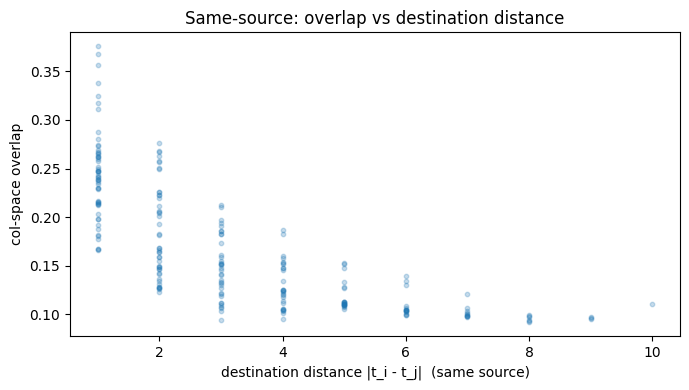

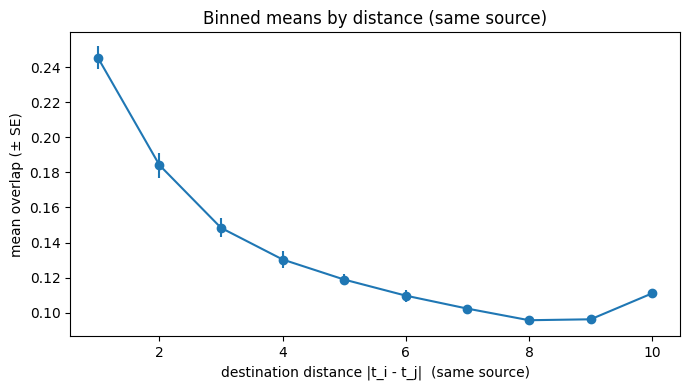

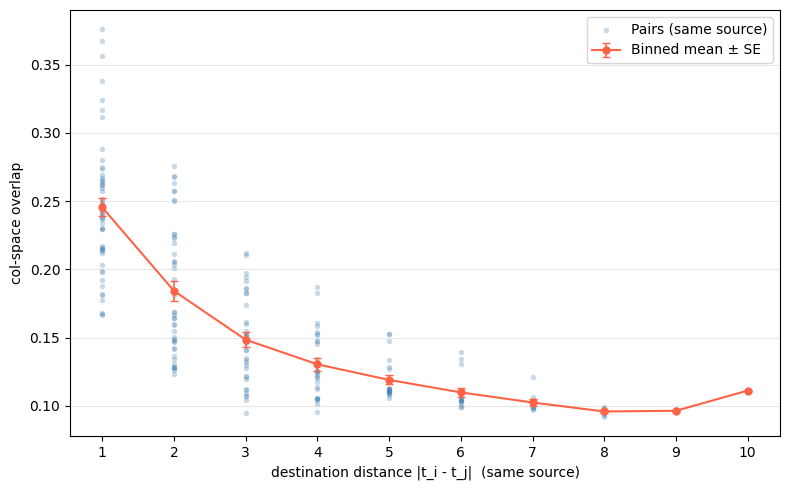

In [15]:

# -----------------------
# 4) 시각화: 거리별 overlap 분포(density) + binned mean
# -----------------------
# (a) scatter
plt.figure(figsize=(7, 4))
plt.scatter(dist2_nz, ov2_nz, s=10, alpha=0.25)
plt.xlabel("destination distance |t_i - t_j|  (same source)")
plt.ylabel("col-space overlap")
plt.title("Same-source: overlap vs destination distance")
plt.tight_layout()
plt.show()

# (b) distance별 평균(및 표준오차) 라인
dmax = int(dist2_nz.max()) if len(dist2_nz) else 0
means = []
ses = []
ds = []
for d in range(1, dmax + 1):
    vals = ov2_nz[dist2_nz == d]
    if len(vals) == 0:
        continue
    ds.append(d)
    means.append(vals.mean())
    ses.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0)

plt.figure(figsize=(7, 4))
plt.errorbar(ds, means, yerr=ses, fmt="o-")
plt.xlabel("destination distance |t_i - t_j|  (same source)")
plt.ylabel("mean overlap (± SE)")
plt.title("Binned means by distance (same source)")
plt.tight_layout()
plt.show()

dmax = int(dist2_nz.max()) if len(dist2_nz) else 0
ds, means, ses = [], [], []

for d in range(1, dmax + 1):
    vals = ov2_nz[dist2_nz == d]
    if len(vals) == 0:
        continue
    ds.append(d)
    means.append(vals.mean())
    ses.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0)

ds = np.array(ds, dtype=int)
means = np.array(means, dtype=float)
ses = np.array(ses, dtype=float)

# -----------------------
# 2) 한 figure에 같이 그리기
# -----------------------
fig = plt.figure(figsize=(8, 5))

# (a) scatter (배경)
plt.scatter(
    dist2_nz, ov2_nz,
    s=15, alpha=0.3, linewidths=0,
    label="Pairs (same source)", color="steelblue"
)

# (b) binned mean + SE (전경)
plt.errorbar(
    ds, means, yerr=ses,
    fmt="o-", capsize=3, elinewidth=1.2, markersize=5,
    label="Binned mean ± SE", color="tomato"
)

plt.xlabel("destination distance |t_i - t_j|  (same source)")
plt.ylabel("col-space overlap")
# plt.title("Same-source: overlap vs destination distance (scatter + binned mean)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.xticks(range(1, dmax + 1))

# 마지막 figure를 PDF로 저장
fig.savefig("overlap_vs_distance.pdf")

plt.show()


In [11]:
import os
import torch

MAP_DIR = "subspace_channel_analysis_r64"
rel_frobs = []
cos_sims = []

for fname in os.listdir(MAP_DIR):
    if not fname.endswith(".pt"):
        continue
    pt = torch.load(os.path.join(MAP_DIR, fname))
    metrics = pt.get("metrics", {}).get("val")
    rel_frob = metrics.get("rel_frob")
    cos_sim = metrics.get("cosine")
    # cos_sim 키 이름이 다르면 수정
    print(f"{fname}: rel_frob={rel_frob}, cos_sim={cos_sim}")
    if rel_frob is not None:
        rel_frobs.append(rel_frob)
    if cos_sim is not None:
        cos_sims.append(cos_sim)

if rel_frobs:
    print(f"\n전체 rel_frob 평균: {sum(rel_frobs) / len(rel_frobs)}")
if cos_sims:
    print(f"전체 cos_sim 평균: {sum(cos_sims) / len(cos_sims)}")

full_map_1_to_9.pt: rel_frob=0.6812541899264541, cos_sim=0.7191041111946106
full_map_6_to_9.pt: rel_frob=0.7134287046837233, cos_sim=0.671880841255188
full_map_9_to_10.pt: rel_frob=0.6577615695736057, cos_sim=0.7055206894874573
full_map_2_to_3.pt: rel_frob=0.6960901126164131, cos_sim=0.6978800892829895
full_map_5_to_6.pt: rel_frob=0.694395700324683, cos_sim=0.6966317296028137
full_map_8_to_11.pt: rel_frob=0.4326170076032675, cos_sim=0.8827191591262817
full_map_0_to_8.pt: rel_frob=0.6801347995041311, cos_sim=0.7272751927375793
full_map_4_to_6.pt: rel_frob=0.7021343398136524, cos_sim=0.6923074722290039
full_map_10_to_11.pt: rel_frob=0.33441567354794455, cos_sim=0.9371689558029175
full_map_7_to_11.pt: rel_frob=0.3933383270162858, cos_sim=0.8769676089286804
full_map_7_to_9.pt: rel_frob=0.7118687164517895, cos_sim=0.6737881302833557
full_map_3_to_6.pt: rel_frob=0.7045659725977499, cos_sim=0.6982348561286926
full_map_5_to_8.pt: rel_frob=0.6919595890611228, cos_sim=0.7031341195106506
full_map

In [6]:
pt['metrics']['val']

{'mse': 4.470451676752418e-05,
 'rmse': 0.006686143714243972,
 'rel_frob': 0.4869213515527293,
 'l2': 0.18441756069660187,
 'cosine': 0.864288330078125,
 'total_energy': 14.480879783630371,
 'resid_energy': 3.4333066940307617,
 'pred_energy': 11.00827407836914,
 'energy_explained': 0.7629075895021489,
 'pred_energy_ratio': 0.7601937342793543}